In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

In [ ]:
df = pd.read_csv("test4.csv")

print(df.shape)
df.head()

(2977, 11)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd,Label
0,2.440556,480.218479,6.965626,17,1172,6.965626,0,17,252,17,ATTACK
1,2.210682,1431.232434,11.761076,26,3164,11.761076,0,26,501,26,ATTACK
2,4.626102,1198.849369,10.159740,47,5546,10.159740,0,47,501,47,ATTACK
3,4.618898,331.247832,5.196044,24,1530,5.196044,0,24,252,24,ATTACK
4,0.047242,20659.719116,169.341960,8,976,169.341960,0,8,501,8,ATTACK


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                2977 non-null   float64
 1   Flow Bytes/s                 2977 non-null   float64
 2   Flow Packets/s               2977 non-null   float64
 3   Total Fwd Packets            2977 non-null   int64  
 4   Total Length of Fwd Packets  2977 non-null   int64  
 5   Fwd Packets/s                2977 non-null   float64
 6   SYN Flag Count               2977 non-null   int64  
 7   ACK Flag Count               2977 non-null   int64  
 8   Init_Win_bytes_forward       2977 non-null   int64  
 9   act_data_pkt_fwd             2977 non-null   int64  
 10  Label                        2977 non-null   object 
dtypes: float64(4), int64(6), object(1)
memory usage: 256.0+ KB
None


In [4]:
df.isnull().sum()

Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packets/s                  0
SYN Flag Count                 0
ACK Flag Count                 0
Init_Win_bytes_forward         0
act_data_pkt_fwd               0
Label                          0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [6]:
df["Label"].value_counts()

Label
ATTACK    2977
Name: count, dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2977.0,3.388894,1.230810,0.006254,2.993603,3.443437,4.406821,4.996923
Flow Bytes/s,2977.0,4483.316844,21847.778581,46.257220,120.464470,240.070162,342.887401,197711.464676
Flow Packets/s,2977.0,9.862546,28.837504,0.676148,1.801373,3.596897,5.165278,479.677951
Total Fwd Packets,2977.0,27.424924,80.967797,3.000000,4.000000,11.000000,18.000000,783.000000
Total Length of Fwd Packets,2977.0,17900.174001,97289.274210,174.000000,240.000000,792.000000,1206.000000,968208.000000
Fwd Packets/s,2977.0,9.862546,28.837504,0.676148,1.801373,3.596897,5.165278,479.677951
SYN Flag Count,2977.0,13.615721,79.395415,0.000000,0.000000,0.000000,3.000000,783.000000
ACK Flag Count,2977.0,14.474639,20.539631,0.000000,3.000000,11.000000,17.000000,189.000000
Init_Win_bytes_forward,2977.0,49172.562983,20787.193762,250.000000,53248.000000,53248.000000,65535.000000,65535.000000
act_data_pkt_fwd,2977.0,18.045684,82.475212,0.000000,0.000000,0.000000,0.000000,783.000000


In [8]:
df.median(numeric_only=True)

Flow Duration                      3.443437
Flow Bytes/s                     240.070162
Flow Packets/s                     3.596897
Total Fwd Packets                 11.000000
Total Length of Fwd Packets      792.000000
Fwd Packets/s                      3.596897
SYN Flag Count                     0.000000
ACK Flag Count                    11.000000
Init_Win_bytes_forward         53248.000000
act_data_pkt_fwd                   0.000000
dtype: float64

In [9]:
features = [
'Flow Duration',
'Flow Bytes/s',
'Flow Packets/s',
'Total Fwd Packets',
'Total Length of Fwd Packets',
'Fwd Packets/s',
'SYN Flag Count',
'ACK Flag Count',
'Init_Win_bytes_forward',
'act_data_pkt_fwd'
]

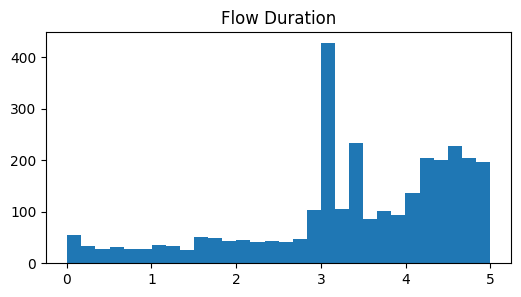

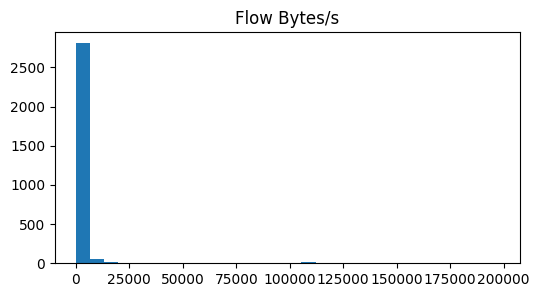

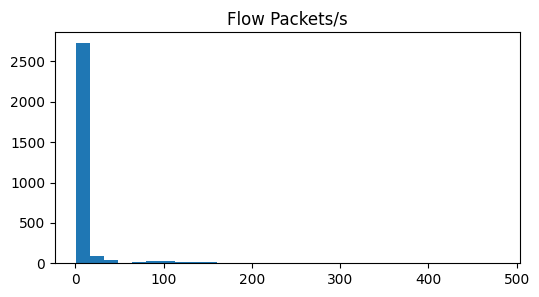

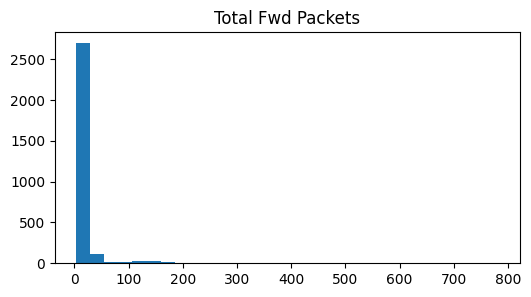

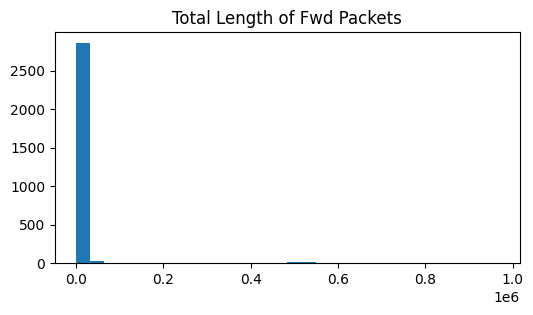

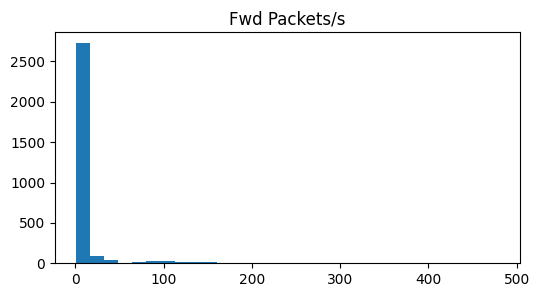

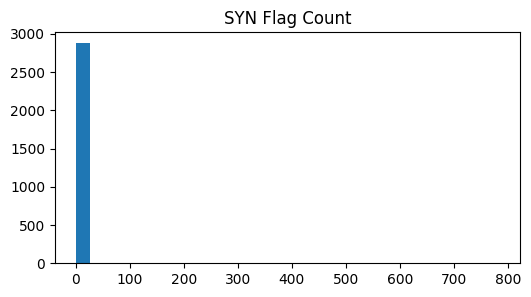

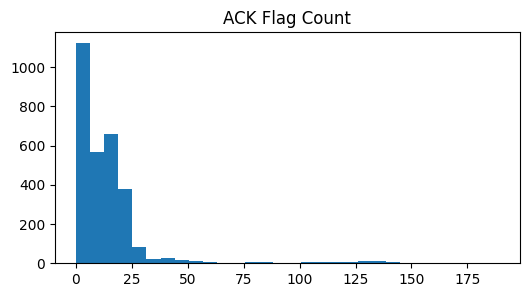

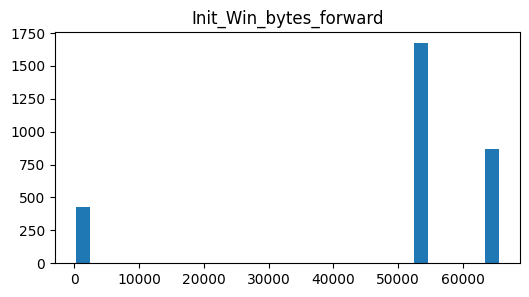

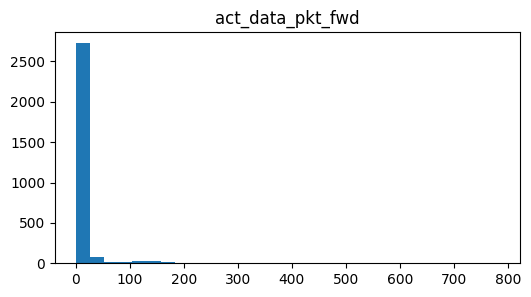

In [10]:
for col in features:

    plt.figure(figsize=(6,3))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.show()

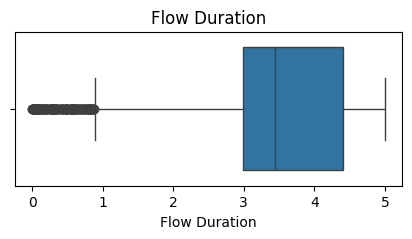

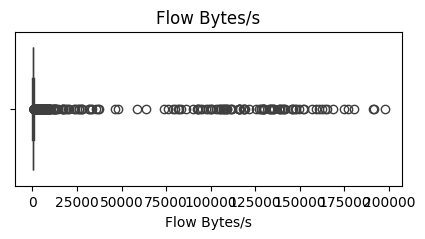

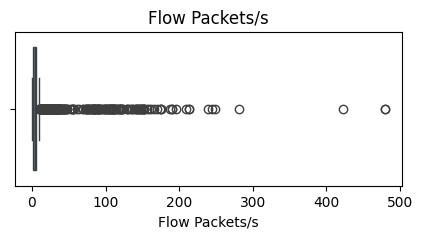

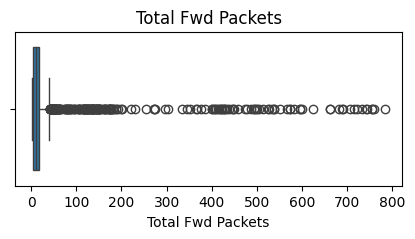

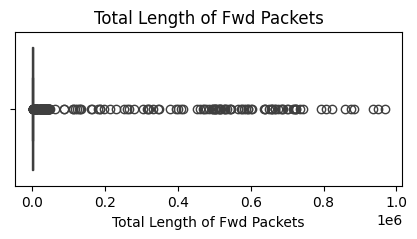

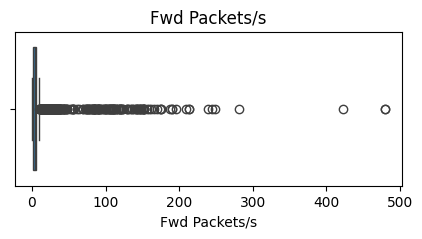

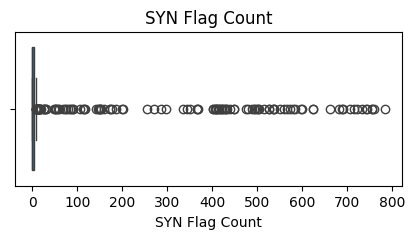

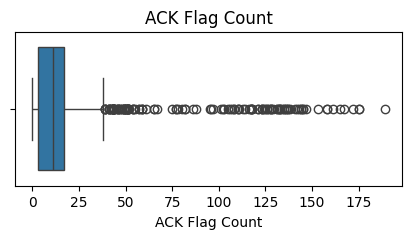

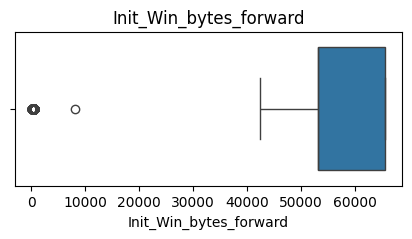

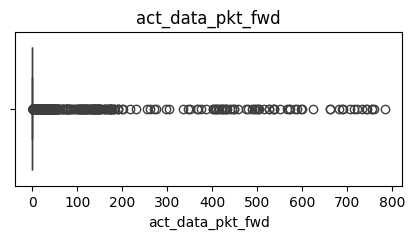

In [11]:
for col in features:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

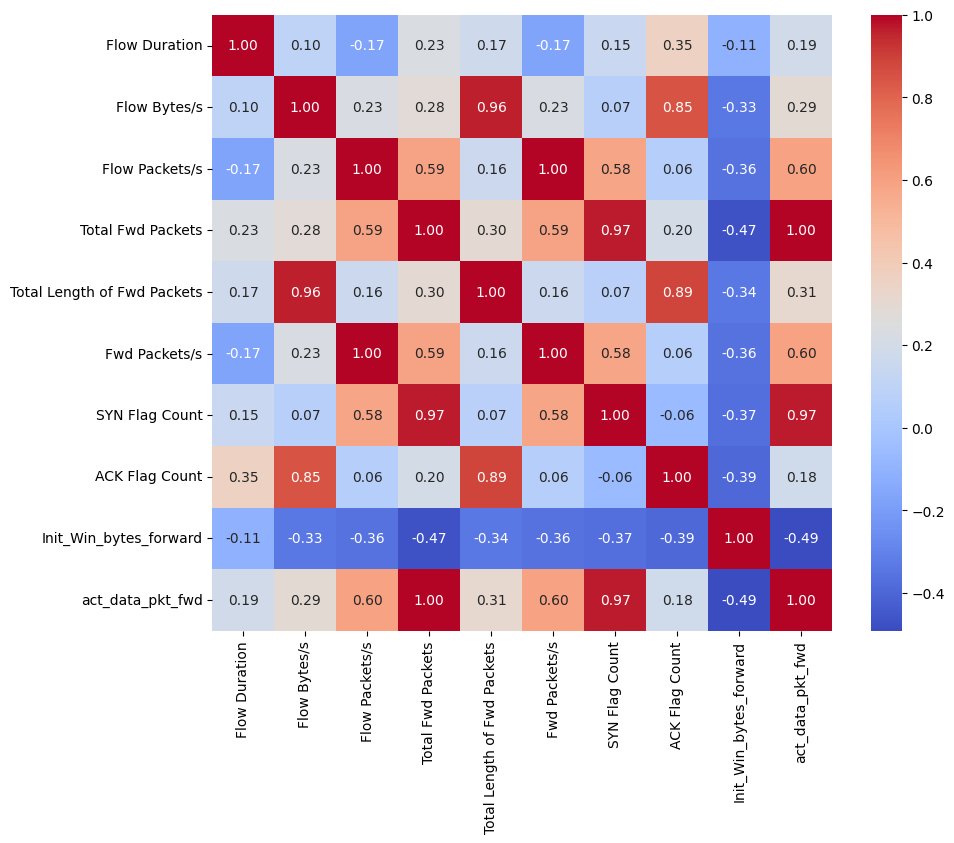

In [12]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [13]:
df[features].var().sort_values()

Flow Duration                  1.514892e+00
ACK Flag Count                 4.218765e+02
Flow Packets/s                 8.316017e+02
Fwd Packets/s                  8.316017e+02
SYN Flag Count                 6.303632e+03
Total Fwd Packets              6.555784e+03
act_data_pkt_fwd               6.802161e+03
Init_Win_bytes_forward         4.321074e+08
Flow Bytes/s                   4.773254e+08
Total Length of Fwd Packets    9.465203e+09
dtype: float64

In [14]:
for col in features:

    print(col)

    print(df[col].nunique())

Flow Duration
2977
Flow Bytes/s
2977
Flow Packets/s
2977
Total Fwd Packets
194
Total Length of Fwd Packets
571
Fwd Packets/s
2977
SYN Flag Count
115
ACK Flag Count
113
Init_Win_bytes_forward
17
act_data_pkt_fwd
196


In [15]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(col, e)

Flow Duration 7.998671361015775
Flow Bytes/s 7.998671361015775
Flow Packets/s 7.998671361015775
Total Fwd Packets 3.3423980074297392
Total Length of Fwd Packets 4.450003223102918
Fwd Packets/s 7.998671361015775
SYN Flag Count 1.183514900617443
ACK Flag Count 3.2243571377334033
Init_Win_bytes_forward 1.3170160434689624
act_data_pkt_fwd 1.2924995596765882


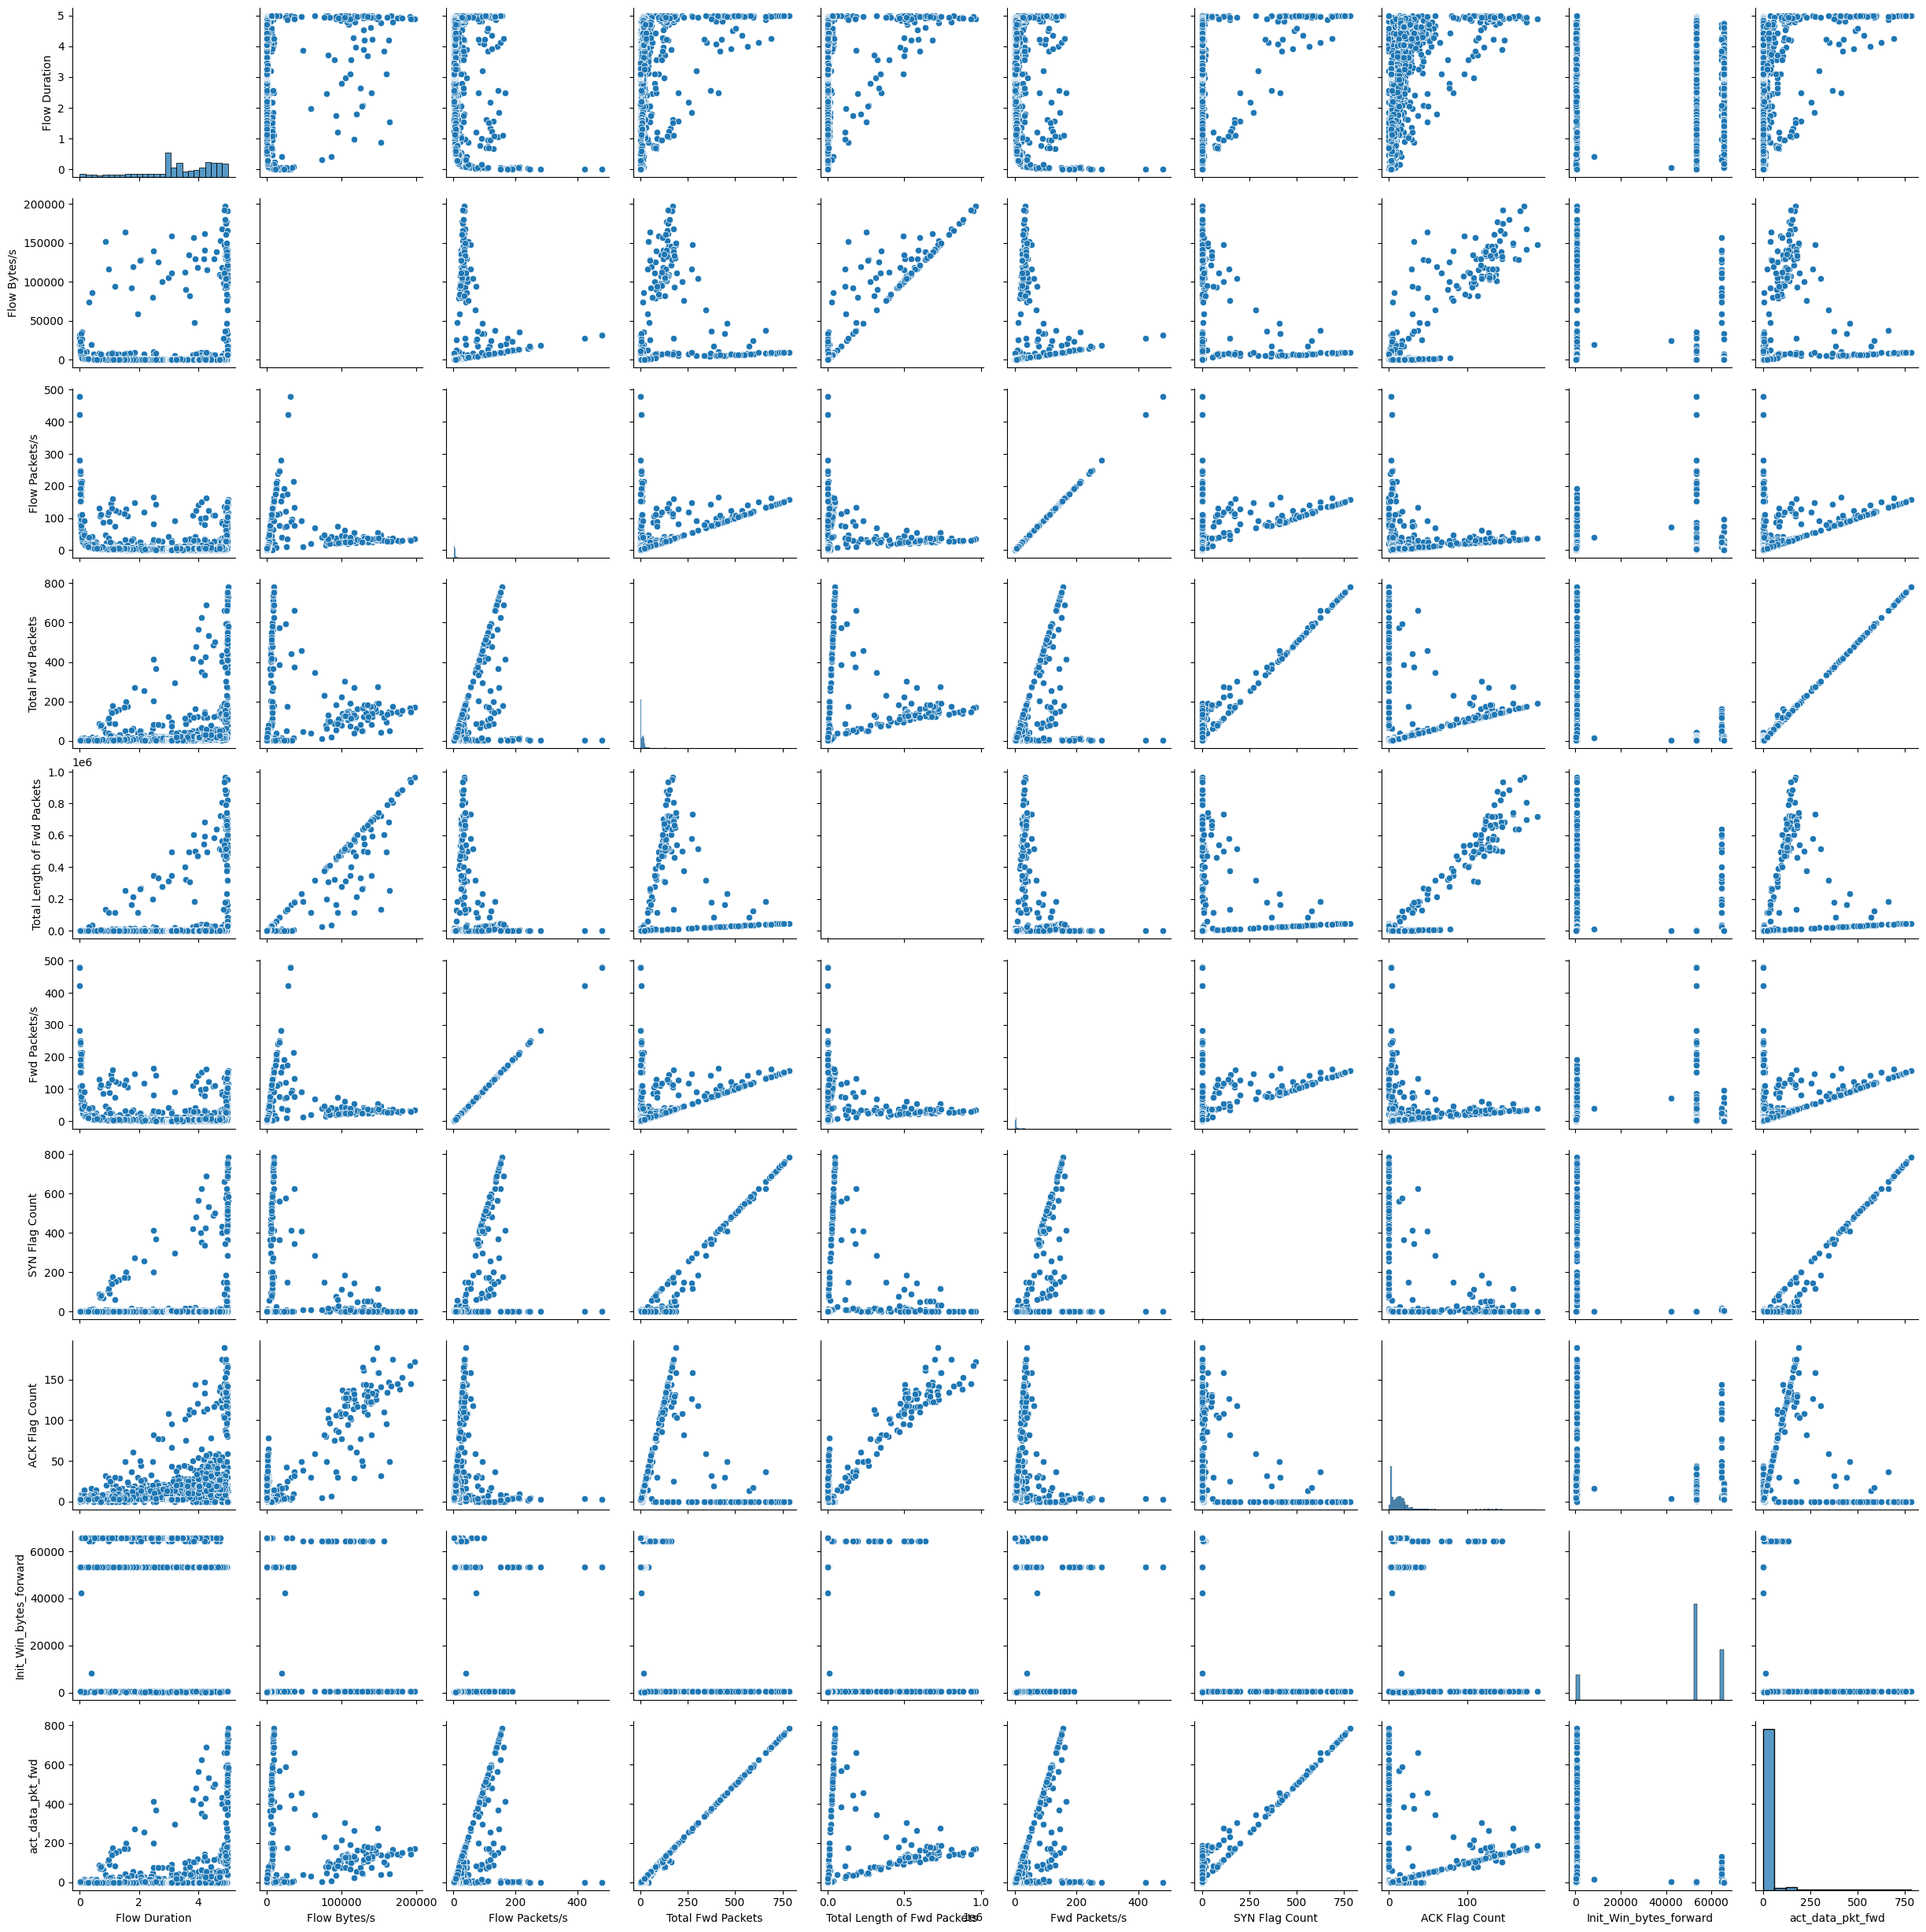

In [16]:
sns.pairplot(
    df[features]
)

In [17]:
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [18]:
X = df[features]

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

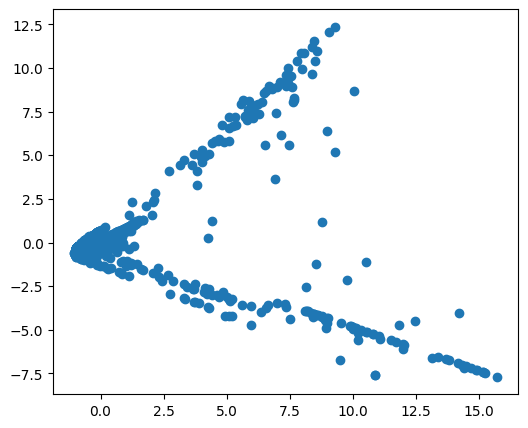

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.show()

In [20]:
corr = abs(df[features].corr())

corr

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd
Flow Duration,1.000000,0.100690,0.169051,0.234291,0.174007,0.169051,0.145763,0.354236,0.106577,0.188170
Flow Bytes/s,0.100690,1.000000,0.230323,0.282974,0.961648,0.230323,0.067419,0.848009,0.334744,0.290488
Flow Packets/s,0.169051,0.230323,1.000000,0.589918,0.159313,1.000000,0.582450,0.060636,0.357988,0.596548
Total Fwd Packets,0.234291,0.282974,0.589918,1.000000,0.299197,0.589918,0.966066,0.197898,0.469189,0.995562
Total Length of Fwd Packets,0.174007,0.961648,0.159313,0.299197,1.000000,0.159313,0.074434,0.885811,0.340248,0.306632
Fwd Packets/s,0.169051,0.230323,1.000000,0.589918,0.159313,1.000000,0.582450,0.060636,0.357988,0.596548
SYN Flag Count,0.145763,0.067419,0.582450,0.966066,0.074434,0.582450,1.000000,0.061499,0.369635,0.966763
ACK Flag Count,0.354236,0.848009,0.060636,0.197898,0.885811,0.060636,0.061499,1.000000,0.393168,0.180422
Init_Win_bytes_forward,0.106577,0.334744,0.357988,0.469189,0.340248,0.357988,0.369635,0.393168,1.000000,0.491825
act_data_pkt_fwd,0.188170,0.290488,0.596548,0.995562,0.306632,0.596548,0.966763,0.180422,0.491825,1.000000


In [21]:
for col in features:

    print(
        col,
        df[col].std()
    )

Flow Duration 1.2308095244082107
Flow Bytes/s 21847.778581491737
Flow Packets/s 28.837504390277697
Total Fwd Packets 80.96779666204614
Total Length of Fwd Packets 97289.27421023755
Fwd Packets/s 28.837504390277697
SYN Flag Count 79.39541453734137
ACK Flag Count 20.539631367987134
Init_Win_bytes_forward 20787.19376156048
act_data_pkt_fwd 82.47521171066121
